## Mateus Ribeiro Gomes - 555225
### Trabalho Densidade Espectral de Potência

In [2]:
import numpy as np
from matplotlib import pyplot as plt

### 1a questão

In [83]:
# Definindo os dados fornecidos
n1 = 1024
n2 = 4096
a1 = 1.35
a2 = -0.85
f0 = 0.45
phi = np.random.uniform(0, 2 * np.pi)
alpha = 0.72
D = 4

#### Função para gerar o 

#### $x(n) = a_1 \cdot x(n-1) + a_2 \cdot x(n-2) + u(n)$

In [84]:
gerar_ruido = lambda n, var : np.random.normal(0, np.sqrt(var), n)

def x(n):
    u = gerar_ruido(n, 1.0) 
    xret = np.zeros(n)
    for i in range(n):
        if i == 0:
            xret[i] = u[i]
        elif i == 1:
            xret[i] = a1 * xret[i-1] + u[i]
        else:
            xret[i] = a1 * xret[i-1] + a2 * xret[i-2] + u[i]
            
    return xret

#### Função para modelar o filtro FIR
#### $h(n) = \delta(n) + \alpha \cdot \delta (n-D)$

In [85]:
def aplicar_canal(x):
    y = np.zeros(len(x))
    # As primeiras D amostras não sofrem interferência 
    y[:D] = x[:D]
    # A partir de D, o sinal é a soma do caminho direto com o percurso atrasado
    y[D:] = x[D:] + alpha * x[:-D]
    return y

#### Função para a interferência
#### $s_{int}(n) = A \cdot cos(2 \pi f_0 n + \phi)$

In [86]:
def sint(n, A):
    return A * np.cos(2*np.pi*f0*n + phi)

#### Função para calcular a variância dada as diferentes relações sinal ruído
#### $SNR_{db} = 10 \cdot log_{10} \cdot \frac{P_{signal}}{P_{noise}}$, queremos achar o $P_{noise}$

In [96]:
def var_given_db(y, db):
    pot = np.mean(y**2)
    var = pot / (10**(db/10))
    return var

#### Função final que combina tudo

In [99]:
def ar2(n, A, snr_db):
    xtemp = x(n)
    y = aplicar_canal(xtemp)
    var_w = var_given_db(y, snr_db)
    sinterf = sint(np.arange(n), A)
    w = gerar_ruido(n, var_w)
    r = y + sinterf + w
    return r

In [100]:
ar_1024 = ar2(n=n1, A=1, snr_db=15)
ar_4096 = ar2(n=n2, A=1, snr_db=15)

#### Plotando

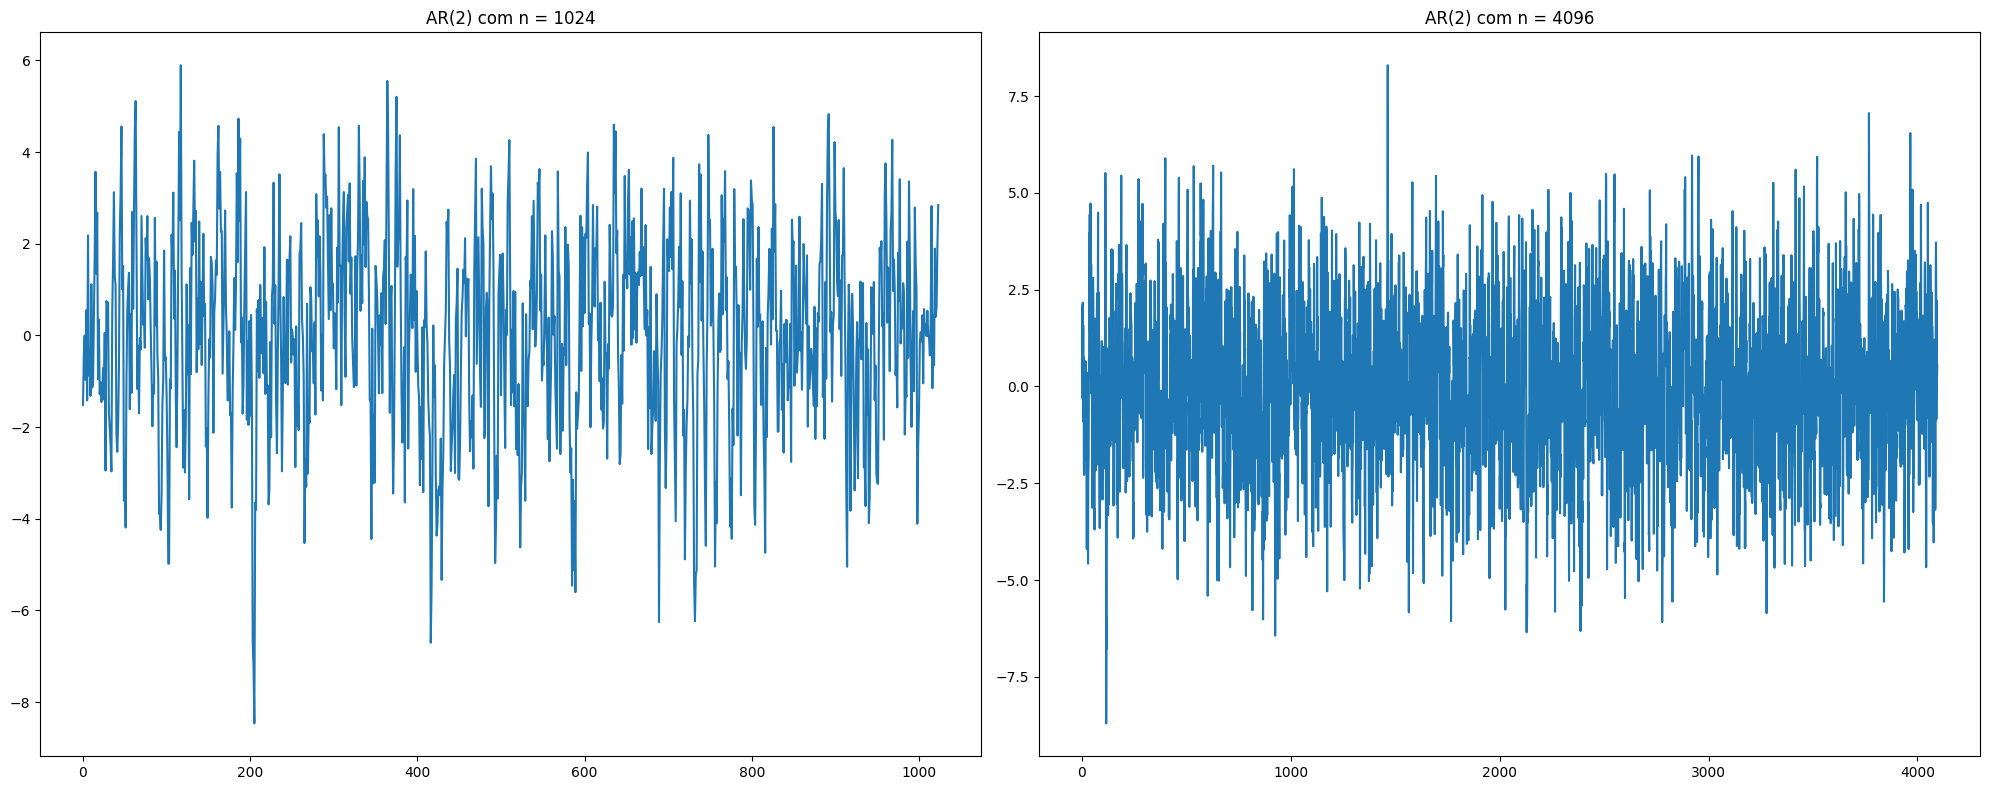

In [101]:
N1 = np.arange(n1)
N2 = np.arange(n2)

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

axs[0].plot(N1, ar_1024)
axs[0].set_title('AR(2) com n = 1024')

axs[1].plot(N2, ar_4096)
axs[1].set_title('AR(2) com n = 4096')

plt.tight_layout()
plt.show()

## 2a questão

#### Variando os valores de "A" e $\sigma^2_w$

In [103]:
As = [0.25, 1, 5, 10]
dbs = [0, 10, 30, 50]
ar2s_1024 = [ar2(n1,a, db) for a in As for db in dbs]
ar2s_4096 = [ar2(n2,a, db) for a in As for db in dbs]

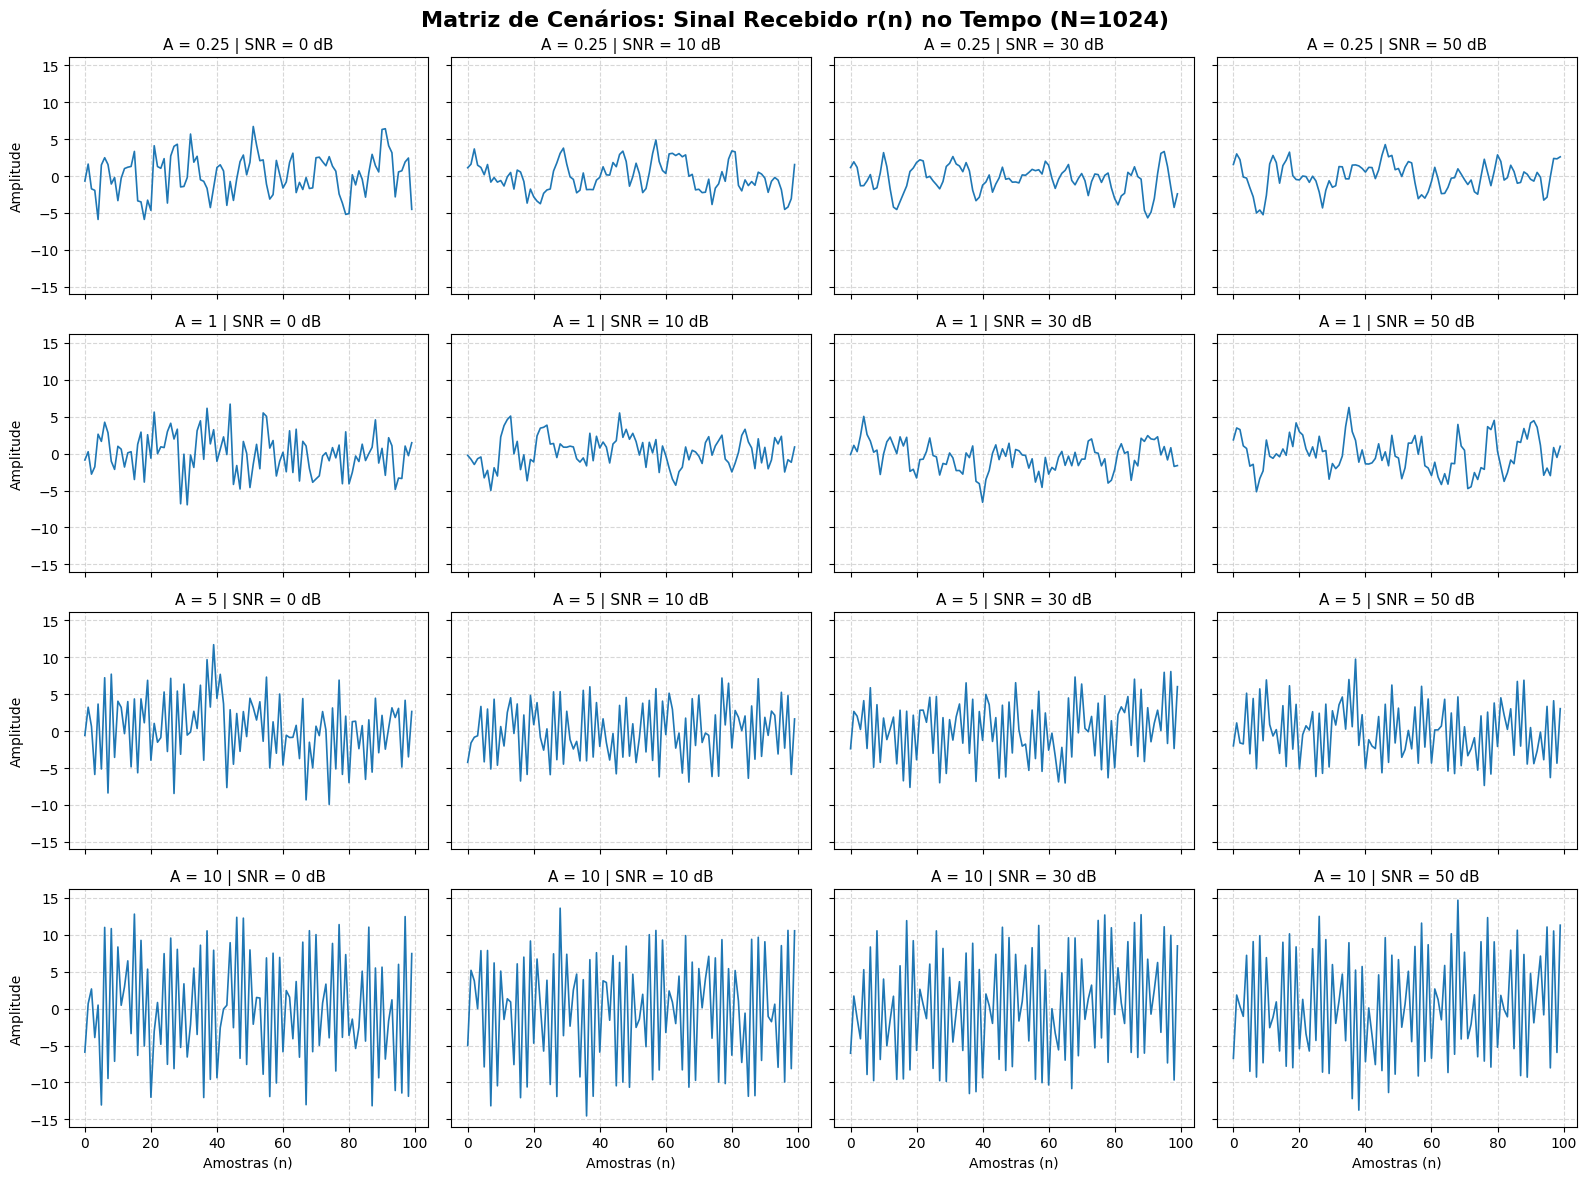

In [117]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('Matriz de Cenários: Sinal Recebido r(n) no Tempo (N=1024)', fontsize=16, fontweight='bold', y=0.98)

indice_sinal = 0

for i, a in enumerate(As):
    for j, db in enumerate(dbs):
        ax = axes[i, j]
        
        ax.plot(ar2s_1024[indice_sinal][:100], color='#1f77b4', linewidth=1.2)
        
        ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 3:
            ax.set_xlabel('Amostras (n)')
        if j == 0:
            ax.set_ylabel('Amplitude')
            
        indice_sinal += 1

plt.tight_layout()
plt.show()

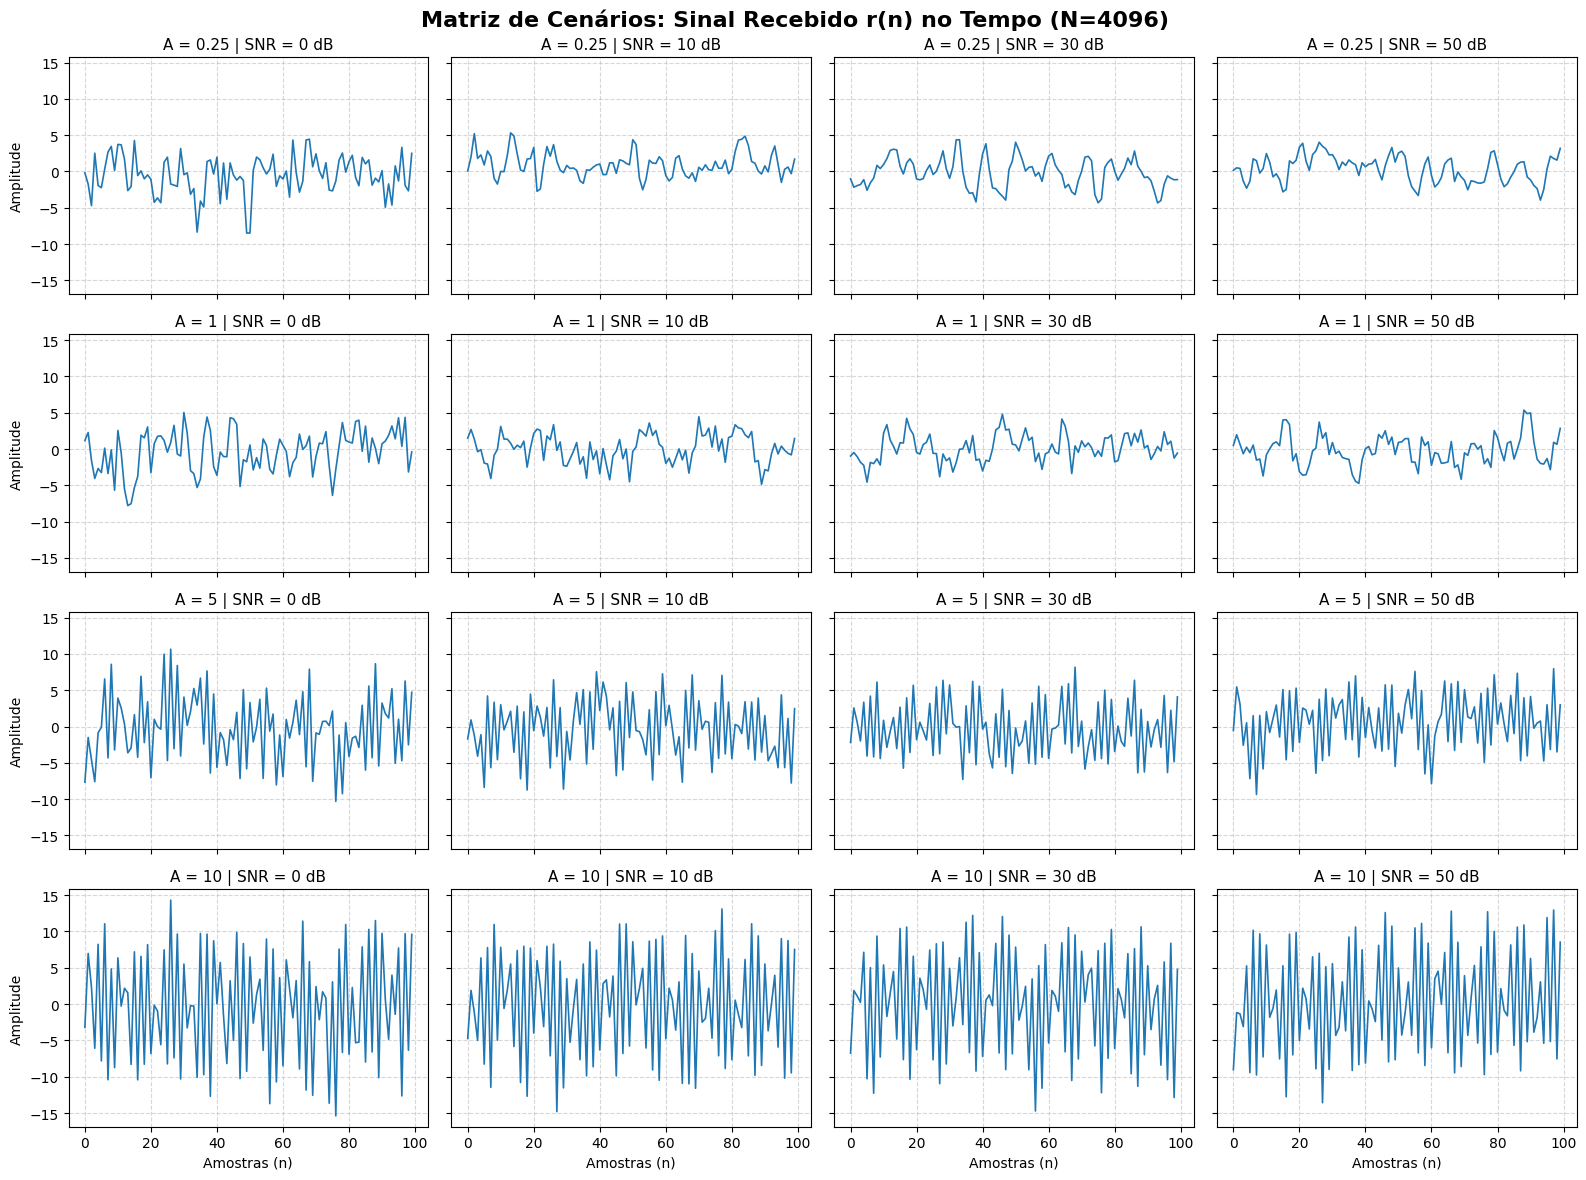

In [118]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('Matriz de Cenários: Sinal Recebido r(n) no Tempo (N=4096)', fontsize=16, fontweight='bold', y=0.98)

indice_sinal = 0

for i, a in enumerate(As):
    for j, db in enumerate(dbs):
        ax = axes[i, j]
        
        ax.plot(ar2s_4096[indice_sinal][:100], color='#1f77b4', linewidth=1.2)
        
        ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 3:
            ax.set_xlabel('Amostras (n)')
        if j == 0:
            ax.set_ylabel('Amplitude')
            
        indice_sinal += 1

plt.tight_layout()
plt.show()

### 3a questão

In [120]:
from scipy import signal

In [4]:
def Sx(f):
    return 1 /(np.abs(1 - a1 * np.exp(-j*2*np.pi*f)) - a2 * np.exp(-j*4*np.pi*f)) ** 2